<a href="https://colab.research.google.com/github/Dass-19/LTSF/blob/main/experiment/LTSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center;">
  <h1>UNIVERSIDAD DE GUAYAQUIL</h1>
  <h2>FACULTAD DE CIENCIAS MATEMÁTICAS Y FÍSICAS</h2>
  <p><i>Carrera de Ingeniería en Ciencia de Datos e Inteligencia Artificial</i></p>
  <br>
  
  <p style="letter-spacing: 1.5px; color: #336699; font-weight: bold;">APRENDIZAJE PROFUNDO Y REFORZADO</p>
  <br>
  
  <h2>Proyecto Parcial: Long-Term Time Series Forecasting (LTSF)</h2>
  <h3><i>Análisis comparativo de modelos LTSF y Redes LSTM con el Dataset ETTh1</i></h3>
  <br>
  
  <p><b>Autores:</b></p>
  <p>Allison Castro &bull; Daniel Suárez &bull; Joselyn Ortega &bull; Magno Barco &bull; Marlon Salazar &bull; Paul Delgado</p>
  <p><i>{allison.castrotap, daniel.suarezsol, joselyn.ortegaver, magno.barcoa, marlon.salazaralv, paul.delgadover}<b>@ug.edu.ec</b></i></p>
  <hr>
</div>

<a href="https://colab.research.google.com/github/Dass-19/LTSF/blob/main/LTSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)
torch.manual_seed(42)

#1. Resumen del paper



El artículo **"Are Transformers Effective for Time Series Forecasting?" (Zeng et al., 2022)** cuestiona la tendencia reciente de utilizar arquitecturas complejas basadas en Transformers para el pronóstico de series de tiempo a largo plazo (LTSF). Aunque los Transformers son excelentes en procesamiento de lenguaje natural debido a su capacidad para capturar dependencias a largo plazo, el paper argumenta que el mecanismo de autoatención pierde el orden temporal estricto de las secuencias, lo cual es vital en series de tiempo.

Los autores proponen un modelo base extremadamente simple llamado LTSF-Linear, compuesto por modelos lineales básicos (Linear, DLinear y NLinear). La formulación matemática central es:
$$ \hat{X}_i = W X_i, \quad W \in \mathbb{R}^{T \times L}  $$

DLinear descompone la serie en tendencia mediante media móvil y componente estacional, modelando cada uno por separado. Por su parte, NLinear normaliza la serie restando el último valor antes de la proyección lineal y luego lo reintegra, mitigando el problema de distribución cambiante entre entrenamiento y prueba.

En los experimentos realizados sobre 9 datasets reales (ETT, Traffic, Electricity, Weather, ILI, Exchange-Rate) con las métricas MSE y MAE, los modelos lineales superan consistentemente a los Transformers del estado del arte (Informer, Autoformer y FEDformer), logrando mejoras que frecuentemente oscilan entre el 20% y 50%. Además, demuestran que los Transformers no mejoran su rendimiento al aumentar la longitud de la ventana de entrada, lo que evidencia su debilidad para capturar relaciones temporales en secuencias largas.
Este trabajo resalta que, en el ámbito del pronóstico de series temporales, la simplicidad puede superar ampliamente a la complejidad.

### Fórmulas del Paper (LTSF-Linear)

**1. LTSF-Linear:**
Predice el horizonte futuro aplicando una transformación afín directa sobre la secuencia histórica $X$.
$$ \hat{X} = W X + b $$
Donde $W \in \mathbb{R}^{T \times L}$ es la matriz de pesos, $L$ es la longitud de la ventana de entrada (look-back) y $T$ es el horizonte de predicción.

**2. DLinear (Decomposition Linear):**
Primero descompone la serie de tiempo en componentes de tendencia ($X_{trend}$) y estacionalidad/residual ($X_{seasonal}$), utilizando promedios móviles, y aplica capas lineales separadas a cada componente:
$$ X_{trend} = \text{MovingAverage}(X) $$
$$ X_{seasonal} = X - X_{trend} $$
$$ \hat{X} = W_{trend} X_{trend} + W_{seasonal} X_{seasonal} $$

**3. NLinear (Normalized Linear):**
Resta el último valor de la secuencia para normalizar, aplica la capa lineal y luego vuelve a sumar el valor:
$$ \hat{X} = W(X - X_{L}) + X_{L} $$
Donde $X_L$ es el último valor observado en la secuencia de entrada.

#2. Dataset

El dataset **ETTh1** (Electric Transformer Temperature) contiene datos registrados de transformadores eléctricos. El objetivo de este notebook es predecir la temperatura del aceite (**OT**, Oil Temperature) basándose en las cargas útiles e inútiles medidas en diferentes niveles (alta, media y baja).

A continuación, se realiza un proceso de limpieza de datos, se analizan los valores faltantes y se exploran las tendencias y estacionalidades de la serie a través de medias móviles y descomposición estacional.


| Field | date | HUFL | HULL | MUFL | MULL | LUFL | LULL | OT |
| :----: | :----: | :----: | :----: | :----: | :----: | :----: | :----: | :----: |
| Description | The recorded **date** |**H**igh **U**se**F**ul **L**oad | **H**igh **U**se**L**ess **L**oad | **M**iddle **U**se**F**ul **L**oad | **M**iddle **U**se**L**ess **L**oad | **L**ow **U**se**F**ul **L**oad | **L**ow **U**se**L**ess **L**oad | **O**il **T**emperature (target) |

In [4]:
ETTh1 = pd.read_csv("https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv")

In [5]:
ETTh1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB


In [6]:
ETTh1['date'] = pd.to_datetime(ETTh1['date'])

In [7]:
ETTh1.head(6)

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
5,2016-07-01 05:00:00,5.626,2.143,1.528,0.533,4.051,1.371,21.174000


In [8]:
ETTh1.isnull().sum()

,0
date,0
HUFL,0
HULL,0
MUFL,0
MULL,0
LUFL,0
LULL,0
OT,0


In [9]:
ETTh1.describe()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


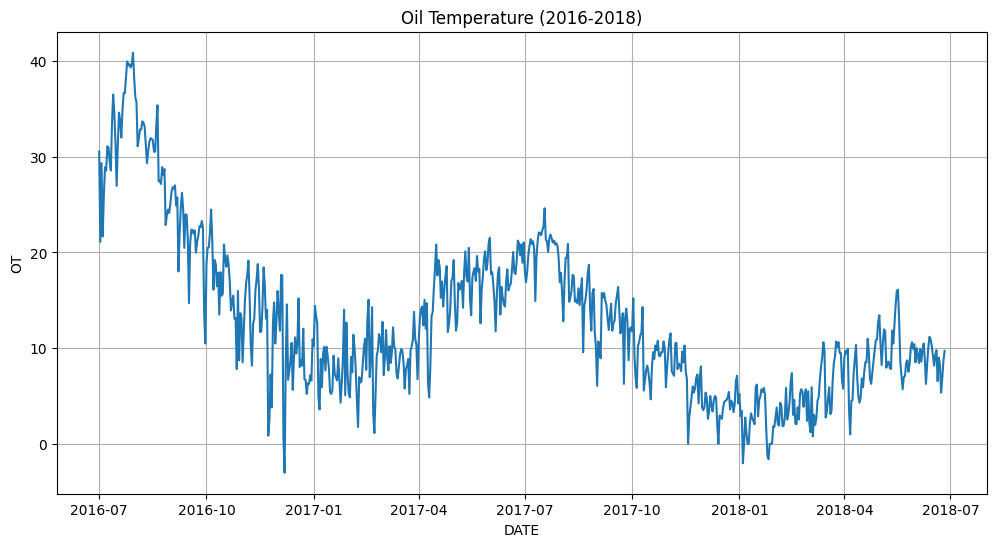

In [10]:
ETTh1_D = ETTh1.copy()
ETTh1_D.index = ETTh1_D.date
ETTh1_D.drop(columns=['date'], inplace=True)
ETTh1_D = ETTh1_D.asfreq('D').dropna()
plt.figure(figsize=(12, 6))
plt.plot(ETTh1_D.OT)
plt.title('Oil Temperature (2016-2018)')
plt.xlabel('DATE')
plt.ylabel('OT')
plt.grid()

In [11]:
ETTh1_D['OT_5'] = ETTh1_D['OT'].rolling(window=5).mean()
ETTh1_D['OT_15'] = ETTh1_D['OT'].rolling(window=15).mean()

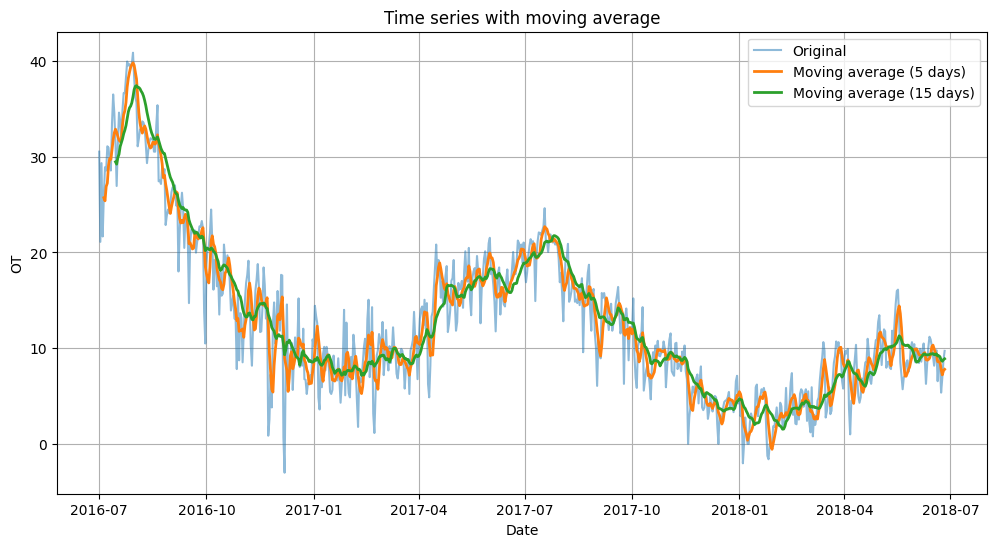

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(ETTh1_D['OT'], label='Original', alpha=0.5)
plt.plot(ETTh1_D['OT_5'], label='Moving average (5 days)', linewidth=2)
plt.plot(ETTh1_D['OT_15'], label='Moving average (15 days)', linewidth=2)
plt.title('Time series with moving average')
plt.xlabel('Date')
plt.ylabel('OT')
plt.legend()
plt.grid()

In [13]:
ETTh1_D.head(15)

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,OT_5,OT_15
date,,,,,,,,,
2016-07-01,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,NaN,NaN
2016-07-02,5.224,3.081,2.701,1.315,2.437,1.523,21.104000,NaN,NaN
2016-07-03,10.382,5.425,7.604,2.310,2.955,1.675,29.334999,NaN,NaN
2016-07-04,9.913,5.894,6.254,2.630,3.015,1.858,21.667000,NaN,NaN
2016-07-05,11.989,5.626,8.777,2.949,3.198,1.980,25.958000,25.7190,NaN
2016-07-06,10.382,5.090,6.467,2.843,3.015,1.828,28.913000,25.3954,NaN
2016-07-07,12.592,5.157,9.204,2.310,2.772,1.614,28.561001,26.8868,NaN
2016-07-08,11.855,4.756,8.884,2.985,2.955,1.523,31.093000,27.2384,NaN
2016-07-09,14.602,5.961,11.300,3.340,3.259,1.767,30.952999,29.0956,NaN


## Descomposición Estacional



Este análisis descompone la serie temporal en tres componentes principales: **Tendencia**, **Estacionalidad** y **Residual**. El objetivo es confirmar visualmente si existen patrones repetitivos (diarios, semanales, etc.) en la temperatura del aceite. Entender la estacionalidad es clave para justificar el uso de codificación cíclica y para evaluar qué tan compleja debe ser la arquitectura del modelo.

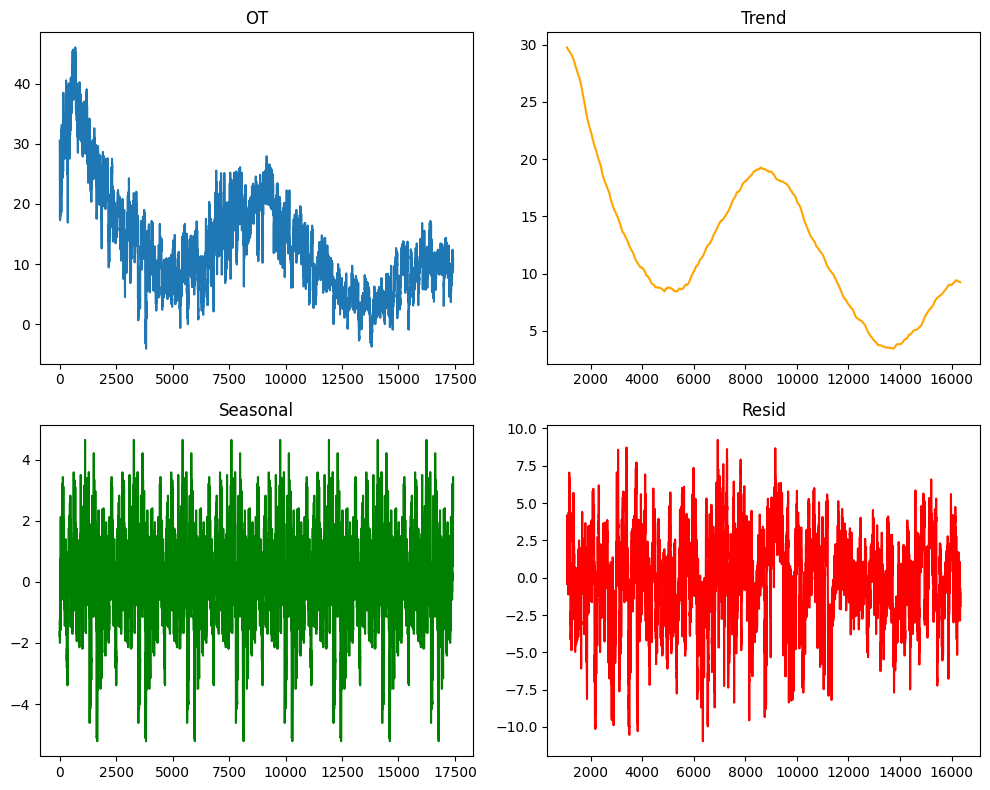

In [14]:
decomposition = seasonal_decompose(ETTh1['OT'], model='additive', period=2160)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(ETTh1['OT'])
plt.title("OT")

plt.subplot(2, 2, 2)
plt.plot(decomposition.trend, color='orange')
plt.title("Trend")

plt.subplot(2, 2, 3)
plt.plot(decomposition.seasonal, color='green')
plt.title("Seasonal")

plt.subplot(2, 2, 4)
plt.plot(decomposition.resid, color='red')
plt.title("Resid")

plt.tight_layout()
plt.show()

## Matriz de Correlación


Se realiza este análisis para **identificar qué variables de entrada (HUFL, HULL, MUFL, etc.) tienen mayor relación lineal con la temperatura del aceite (OT)**.


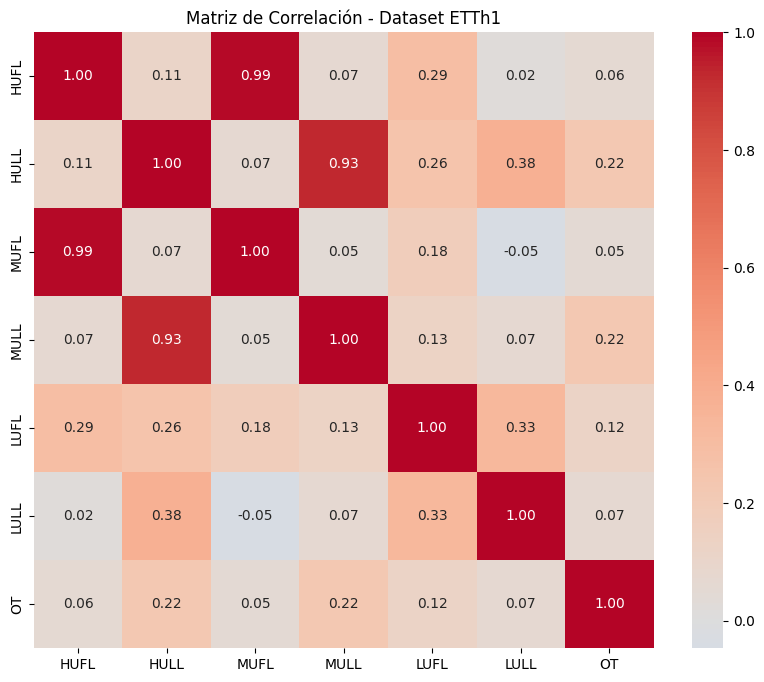

In [13]:
plt.figure(figsize=(10, 8))
corr = ETTh1.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Dataset ETTh1')
plt.show()

## Análisis Avanzado del Target (OT)



Este análisis nos permite entender la **forma de la distribución** de la variable objetivo `OT`. La skewness indica si los datos están sesgados hacia la izquierda o derecha, mientras que la kurtosis nos muestra si existen valores extremos (colas pesadas). Conocer estas características es importante porque influye en la elección de modelos, funciones de pérdida y en la interpretación de los errores del modelo.

In [14]:
target = 'OT'

print("=== Análisis Estadístico Avanzado de OT ===")
print(f"Skewness: {ETTh1[target].skew():.4f}")
print(f"Kurtosis: {ETTh1[target].kurtosis():.4f}")

=== Análisis Estadístico Avanzado de OT ===
Skewness: 0.9683
Kurtosis: 0.7783


### Distribución Empírica de Z-scores del Objetivo (OT)


Para entender cómo se comporta la variable objetivo `OT` bajo la normalización $Z$-score y contextualizar por qué los errores estandarizados son adimensionales, la siguiente celda calcula y grafica la **distribución real de las puntuaciones Z** de los datos del transformador eléctrico frente a una distribución normal teórica $\mathcal{N}(0, 1)$. Esto ilustra la dispersión física de los datos y cómo el modelo se sitúa frente a desviaciones típicas.

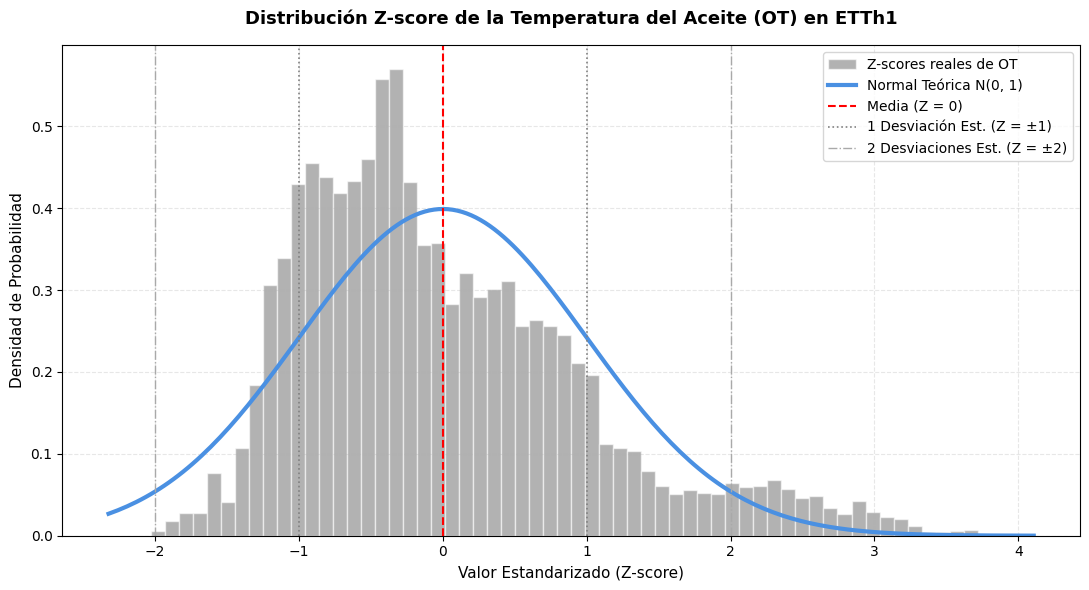

Métricas Estadísticas de la Temperatura de Aceite (Target OT):
Media (µ): 13.3247 °C
Desviación Est. (σ): 8.5667 °C
Rango de Z-scores reales: desde -2.03 hasta 3.82


In [15]:
# 1. Obtener la variable objetivo original (OT)
ot_data = ETTh1['OT'].values

# 2. Calcular media y desviación estándar
mu_ot = np.mean(ot_data)
sigma_ot = np.std(ot_data)

# 3. Calcular Z-scores reales de los datos
ot_zscores = (ot_data - mu_ot) / sigma_ot

# 4. Graficar la distribución
plt.figure(figsize=(11, 6))

# Histograma de los Z-scores reales de los datos
count, bins, ignored = plt.hist(ot_zscores, bins=60, density=True, alpha=0.6, color='gray', edgecolor='white', label='Z-scores reales de OT')

# Densidad normal teórica N(0, 1) calculada con NumPy puro
xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 200)
pdf_theoretical = (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_axis**2)
plt.plot(x_axis, pdf_theoretical, color='#4A90E2', linewidth=3, linestyle='-', label='Normal Teórica N(0, 1)')

# Líneas de referencia para desviaciones estándar
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Media (Z = 0)')
plt.axvline(x=1, color='gray', linestyle=':', linewidth=1.2, label='1 Desviación Est. (Z = ±1)')
plt.axvline(x=-1, color='gray', linestyle=':', linewidth=1.2)
plt.axvline(x=2, color='darkgray', linestyle='-.', linewidth=1, label='2 Desviaciones Est. (Z = ±2)')
plt.axvline(x=-2, color='darkgray', linestyle='-.', linewidth=1)

# Estilización de la gráfica
plt.title('Distribución Z-score de la Temperatura del Aceite (OT) en ETTh1', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Valor Estandarizado (Z-score)', fontsize=11)
plt.ylabel('Densidad de Probabilidad', fontsize=11)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("Métricas Estadísticas de la Temperatura de Aceite (Target OT):")
print(f"Media (µ): {mu_ot:.4f} °C")
print(f"Desviación Est. (σ): {sigma_ot:.4f} °C")
print(f"Rango de Z-scores reales: desde {np.min(ot_zscores):.2f} hasta {np.max(ot_zscores):.2f}")

### Train/Test Split y Distribution Shift

Dividimos el dataset en conjunto de entrenamiento (80%) y prueba (20%) manteniendo el orden temporal. Luego comparamos las distribuciones de `OT` en ambos conjuntos para detectar si existe **distribution shift** (cambio en la distribución a lo largo del tiempo). Este análisis es fundamental en series temporales porque un fuerte shift puede explicar posibles diferencias de rendimiento entre entrenamiento y prueba.

Train: 13936 (80.0%)
Test:  3484 (20.0%)


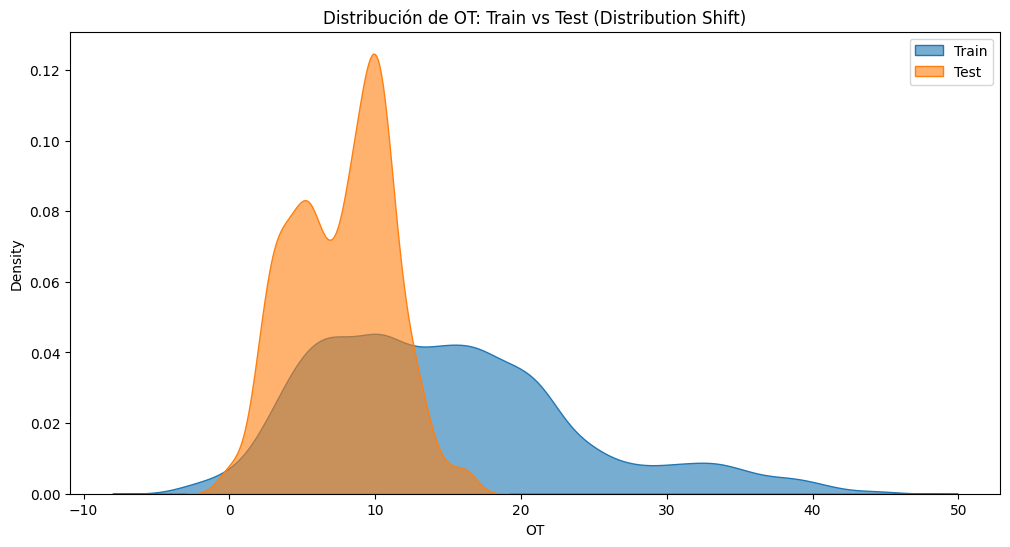


Media Train: 14.7255 | Media Test: 7.7213
Std Train:   8.8860  | Std Test:   3.4464


In [16]:
train_size = int(len(ETTh1) * 0.8)
train = ETTh1.iloc[:train_size]
test = ETTh1.iloc[train_size:]

print(f"Train: {len(train)} ({len(train)/len(ETTh1)*100:.1f}%)")
print(f"Test:  {len(test)} ({len(test)/len(ETTh1)*100:.1f}%)")

plt.figure(figsize=(12, 6))
sns.kdeplot(train[target], label='Train', fill=True, alpha=0.6)
sns.kdeplot(test[target], label='Test', fill=True, alpha=0.6)
plt.title('Distribución de OT: Train vs Test (Distribution Shift)')
plt.legend()
plt.show()

print(f"\nMedia Train: {train[target].mean():.4f} | Media Test: {test[target].mean():.4f}")
print(f"Std Train:   {train[target].std():.4f}  | Std Test:   {test[target].std():.4f}")

#3. Implementación



En contraste con los modelos puramente lineales propuestos en el paper, en este notebook implementaremos una **Long Short-Term Memory (LSTM)** utilizando PyTorch. Las LSTMs son una arquitectura de Redes Neuronales Recurrentes (RNNs) que han sido tradicionalmente el estándar para modelar secuencias temporales.

La clase `LSTM` a continuación incluye:
- Una arquitectura multicapa (2 capas ocultas).
- Inicialización de pesos de Xavier para mejorar la convergencia.
- Regularización mediante **Dropout** y *Weight Decay* (L2) dentro del optimizador AdamW.
- Un programador de tasa de aprendizaje (`ReduceLROnPlateau`) y *Early Stopping* para prevenir el sobreajuste (overfitting).


## Fórmulas de la LSTM (Long Short-Term Memory)



La celda de la LSTM que implementamos resuelve el problema del desvanecimiento del gradiente a través de sus puertas (gates). Las ecuaciones de estado para cada paso de tiempo $t$ son:

$$
\begin{align*}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(Forget Gate)} \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(Input Gate)} \\
\tilde{C}_t &= \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{(Candidate Cell State)} \\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(Cell State)} \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(Output Gate)} \\
h_t &= o_t \odot \tanh(C_t) \quad \text{(Hidden State)}
\end{align*}
$$

In [17]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3, lr=5e-4):
        super().__init__()

        # Parámetros
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.lr = lr

        # Capas
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.drop = nn.Dropout(dropout)

        # Loss y optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.AdamW(
            self.parameters(),
            lr=lr,
            betas=(0.9, 0.999),
            eps= 1e-8,
            weight_decay=0.01,
            amsgrad = False
        )

        # Scheduler: baja el LR si val_loss no mejora en 3 épocas
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,      # LR *= 0.5 cuando se activa
            patience=15,      # espera 3 épocas sin mejora
            min_lr=1e-6,
        )

        # Tracking
        self.train_losses = []
        self.val_losses = []

        # Xavier_Uniform (Bueno para tanh/sigmoid)
        self._init_weights()

    def _init_weights(self):
        # Capa lineal
        nn.init.xavier_uniform_(self.fc.weight)
        if self.fc.bias is not None:
          # Inicializar Bias en 0
          nn.init.constant_(self.fc.bias, 0.0)

        # Capa LSTM
        for name, param in self.lstm.named_parameters():
          if 'weight_ih' in name:
            # Pesos de entrada a oculto
            nn.init.xavier_uniform_(param.data)

          elif 'weight_hh' in name:
            # Pesos de oculto a oculto
            nn.init.xavier_uniform_(param.data)

          elif 'bias' in name:
            # Inicializar Bias en 0
            nn.init.constant_(param.data, 0.0)
            # Forzamos el Bias de la forget gate en 1 para ayudar al gradiente
            n = param.size(0)
            param.data[n//4:n//2].fill_(1.0) # [i_gate, f_gate, g_gate, o_gate]

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        return: (batch, output_size)
        """
        # (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)

        # (batch, hidden_size)
        last_time_step = lstm_out[:, -1, :]

        # Dropout and linear layer
        out = self.fc(self.drop(last_time_step))

        return out

    def train_epoch(self, train_loader):
        """Entrena un epoch."""
        self.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.cuda()
            y_batch = y_batch.cuda()

            # Forward
            pred = self(X_batch)
            loss = self.criterion(pred, y_batch)

            # Backward
            self.optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=5.0)

            self.optimizer.step()
            epoch_loss += loss.item()

        return epoch_loss / len(train_loader)

    def validate(self, val_loader):
        """Valida el modelo."""
        self.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.cuda()
                y_batch = y_batch.cuda()

                pred = self(X_batch)
                loss = self.criterion(pred, y_batch)
                val_loss += loss.item()

        return val_loss / len(val_loader)

    def fit(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32, verbose=True, patience=15):
        """
        Entrena el modelo.

        Args:
            X_train: (n_samples, seq_len, input_size)
            y_train: (n_samples, output_size)
            X_val: (n_samples, seq_len, input_size)
            y_val: (n_samples, output_size)
            epochs: número de epochs
            batch_size: tamaño del batch
            verbose: print info cada epoch
        """
        # Crear dataloaders
        train_data = TensorDataset(
            torch.from_numpy(X_train).float(),
            torch.from_numpy(y_train).float()
            )
        val_data = TensorDataset(
            torch.from_numpy(X_val).float(),
            torch.from_numpy(y_val).float()
            )

        train_loader = DataLoader(
            train_data,
            batch_size=batch_size,
            shuffle=True
            )
        val_loader = DataLoader(
            val_data,
            batch_size=batch_size
            )

        # Mover modelo a GPU
        self.cuda()

        print("Training parameters: \n")
        print(f"Epochs: {epochs}")
        print(f"Batch size: {batch_size}")
        print(f"Learning rate: {self.lr}")
        print(f"Loss: MSELoss")
        print(f"Optimizer: Adam")
        print(f"Gradient clipping: max_norm=5.0\n")
        #--- Variables del Early Stopping ---
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_weights = None # Guardaremos los pesos óptimos en memoria RAM

        # Reiniciar historiales por si se re-entrena
        self.train_losses = []
        self.val_losses = []

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)

            # Guardar histórico para graficar después
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            if verbose:
                print(f"epoch {epoch+1:3d}/{epochs} | train_loss: {train_loss:.6f} | val_loss: {val_loss:.6f}")

            # --- Lógica de Early Stopping ---
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Hacemos una copia profunda de los mejores pesos en la RAM
                best_model_weights = {k: v.cpu().clone() for k, v in self.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\n[Early Stopping] Entrenamiento interrumpido en la época {epoch+1}")
                    print(f"[Early Stopping] La pérdida de validación no mejoró durante {patience} épocas.")
                    break

        # Al salir del bucle, restauramos los pesos del mejor punto histórico
        if best_model_weights is not None:
            self.load_state_dict(best_model_weights)
            self.cuda()  # Lo devolvemos a la GPU listo para predecir
            print(f"Los mejores pesos han sido cargados (Val Loss Mínimo alcanzado: {best_val_loss:.6f})\n")

    def predict(self, X):
        """
        Predice sobre datos nuevos.

        Args:
            X: (n_samples, seq_len, input_size)

        Returns:
            predicciones: (n_samples, output_size)
        """
        self.eval()
        X = torch.from_numpy(X).float().cuda()

        with torch.no_grad():
            pred = self(X)

        return pred.cpu().numpy()

    def plot_losses(self):
        """Grafica train vs val loss."""
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Train Loss', linewidth=2)
        plt.plot(self.val_losses, label='Val Loss', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Diagrama de la arquitectura LSTM implementada

![model_architecture.png](attachment:model_architecture.png)

#4. Entrenamiento y evaluación

En esta sección, se definen los hiperparámetros globales para el entrenamiento. El modelo se evaluará en dos horizontes de predicción ($H=96$ y $H=336$), que corresponden a previsiones de mediano y largo plazo.

Se aplica un **Codificación Cíclica (Seno/Coseno)** a las variables temporales (hora, día de la semana, mes) extraídas de la fecha. Esto permite a la red neuronal entender la continuidad temporal; por ejemplo, que la hora 23 está a una hora de distancia de la hora 0.
Luego, se escalan los datos (Min-Max Scaler) y se crean las secuencias usando ventanas deslizantes (look-back windows) de manera adaptativa.


## Fórmulas de Preprocesamiento



**1. Min-Max Scaler:**
Se utiliza para normalizar los datos en el rango $[0, 1]$, estabilizando el entrenamiento de la LSTM.
$$ X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}} $$

**2. Codificación Cíclica (Seno/Coseno):**
Transforma las características temporales (hora, día, mes) para mantener la relación de continuidad temporal (periodo $P$).
$$ X_{sin} = \sin\left(\frac{2\pi x}{P}\right) $$
$$ X_{cos} = \cos\left(\frac{2\pi x}{P}\right) $$

## Hiperparámetros

In [18]:
TRAIN_SIZE = 0.8
TARGET = 'OT'

HORIZONS = [96, 336]
EPOCHS = 50
DROPOUT = 0.4
LR = 3e-4
# Look-back window
SEQ_LEN_MAP = {
    96: 168,
    336: 288
    }

BATCH_SIZE = 32
LSTM_LAYERS= 2
HIDDEN_SIZE = 128

## Feature engineering

In [19]:
ETTh1 = ETTh1.sort_values(by='date')
# Global timestamps
ETTh1['HOUR_SIN']        = np.sin(2 * np.pi * ETTh1['date'].dt.hour        / 24)
ETTh1['HOUR_COS']        = np.cos(2 * np.pi * ETTh1['date'].dt.hour        / 24)
ETTh1['DOW_SIN']         = np.sin(2 * np.pi * ETTh1['date'].dt.dayofweek  / 7)
ETTh1['DOW_COS']         = np.cos(2 * np.pi * ETTh1['date'].dt.dayofweek  / 7)
ETTh1['MONTH_SIN']       = np.sin(2 * np.pi * ETTh1['date'].dt.month       / 12)
ETTh1['MONTH_COS']       = np.cos(2 * np.pi * ETTh1['date'].dt.month       / 12)

## Feature selection

In [20]:
features = [
    'HUFL',
    'HULL',
    'MUFL',
    'MULL',
    'LUFL',
    'LULL',
    'OT',
    'HOUR_SIN',
    'HOUR_COS',
    'DOW_SIN',
    'DOW_COS',
    'MONTH_SIN',
    'MONTH_COS'
]
cols = features + [TARGET]

data = ETTh1[cols].values.astype(np.float32)

## Train/Validation

In [19]:
split = int(TRAIN_SIZE * len(data))
train_data = data[:split]
val_data = data[split:]

train_min = train_data.min(axis=0)
train_max = train_data.max(axis=0)
denominator = np.where((train_max - train_min) == 0, 1, (train_max - train_min))

train_data_scaled = (train_data - train_min) / denominator
val_data_scaled = (val_data - train_min) / denominator

In [20]:
def create_sequences_multivariate(data, horizon, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len - horizon):
        X.append(data[i : i+seq_len, :-1])
        y.append(data[i+seq_len : i+seq_len+horizon, -1])

    return np.array(X), np.array(y)

Horizon: 96 | SEQ_LEN: 168

LSTM(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=128, out_features=96, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
  (criterion): MSELoss()
)
Training parameters: 

Epochs: 50
Batch size: 32
Learning rate: 0.0003
Loss: MSELoss
Optimizer: Adam
Gradient clipping: max_norm=5.0

epoch   1/50 | train_loss: 0.037069 | val_loss: 0.004440
epoch   2/50 | train_loss: 0.011305 | val_loss: 0.005537
epoch   3/50 | train_loss: 0.008706 | val_loss: 0.006995
epoch   4/50 | train_loss: 0.007326 | val_loss: 0.004018
epoch   5/50 | train_loss: 0.006604 | val_loss: 0.009239
epoch   6/50 | train_loss: 0.005974 | val_loss: 0.004245
epoch   7/50 | train_loss: 0.005626 | val_loss: 0.006168
epoch   8/50 | train_loss: 0.005170 | val_loss: 0.006338
epoch   9/50 | train_loss: 0.004865 | val_loss: 0.008785
epoch  10/50 | train_loss: 0.004777 | val_loss: 0.008850
epoch  11/50 | train_loss: 0.004296 | val_loss: 0.006692
epoch  12

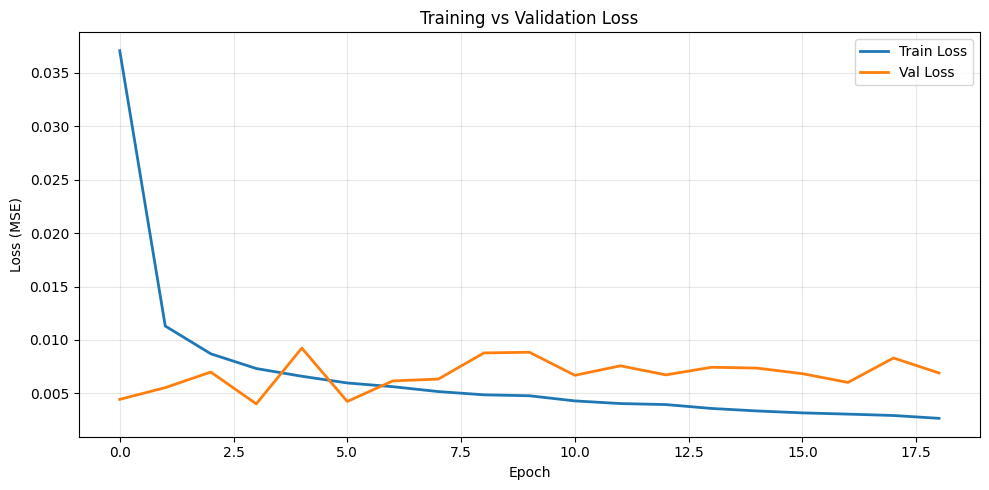


MSE: 10.089793 | RMSE: 3.176443 | MAE: 2.522103

Horizon: 336 | SEQ_LEN: 288

LSTM(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=128, out_features=336, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
  (criterion): MSELoss()
)
Training parameters: 

Epochs: 50
Batch size: 32
Learning rate: 0.0003
Loss: MSELoss
Optimizer: Adam
Gradient clipping: max_norm=5.0

epoch   1/50 | train_loss: 0.027924 | val_loss: 0.008129
epoch   2/50 | train_loss: 0.009278 | val_loss: 0.008250
epoch   3/50 | train_loss: 0.007476 | val_loss: 0.008235
epoch   4/50 | train_loss: 0.006598 | val_loss: 0.006477
epoch   5/50 | train_loss: 0.006005 | val_loss: 0.008953
epoch   6/50 | train_loss: 0.005626 | val_loss: 0.013218
epoch   7/50 | train_loss: 0.005458 | val_loss: 0.009299
epoch   8/50 | train_loss: 0.005336 | val_loss: 0.005972
epoch   9/50 | train_loss: 0.004927 | val_loss: 0.013343
epoch  10/50 | train_loss: 0.004738 | val_loss: 0.012570
epoch  11/50 |

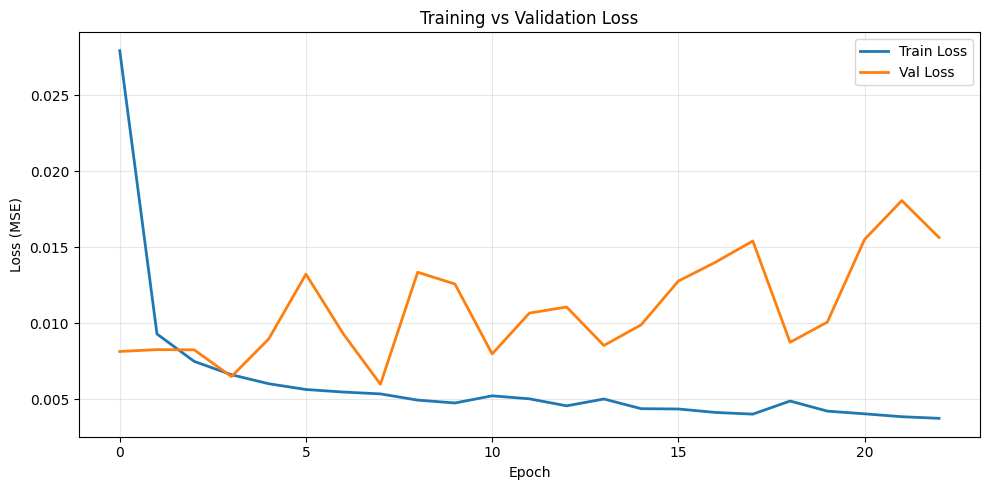


MSE: 14.894780 | RMSE: 3.859376 | MAE: 3.242934



In [21]:
for h in HORIZONS:
  seq_len = SEQ_LEN_MAP[h]
  print(f"Horizon: {h} | SEQ_LEN: {seq_len}\n")
  X_train, y_train = create_sequences_multivariate(
      train_data_scaled,
      horizon=h,
      seq_len=seq_len
      )

  X_val, y_val = create_sequences_multivariate(
      val_data_scaled,
      horizon=h,
      seq_len=seq_len
      )

  model = LSTM(
      input_size=len(features),
      hidden_size=HIDDEN_SIZE,
      num_layers=LSTM_LAYERS,
      output_size=h,
      dropout=DROPOUT,
      lr=LR
      )

  print(model)

  model.fit(
      X_train, y_train,
      X_val, y_val,
      epochs=EPOCHS,
      batch_size=BATCH_SIZE,
      patience = 15
      )

  model.plot_losses()

  y_pred = model.predict(X_val)

  # Desnormalización de métricas
  min_ot = train_min[-1]
  denom_ot = denominator[-1]
  y_val_original = y_val * denom_ot + min_ot
  y_pred_original = y_pred * denom_ot + min_ot

  mse = mean_squared_error(y_val_original, y_pred_original)
  mae = mean_absolute_error(y_val_original, y_pred_original)
  rmse = np.sqrt(mse)

  print(f"\nMSE: {mse:.6f} | RMSE: {rmse:.6f} | MAE: {mae:.6f}\n")

Baseline del Paper:


```https://arxiv.org/abs/2205.13504```
- Multivariate Forecasting

| Methods | Metric | 96 | 336 |
| :--- | :--- | :--- | :--- |
| **Linear** | MSE | 0.375 | 0.479 |
| | MAE | 0.397 | 0.476 |
| **NLinear** | MSE | 0.374 | 0.429 |
| | MAE | 0.394 | 0.427 |
| **DLinear** | MSE | 0.375 | 0.439 |
| | MAE | 0.399 | 0.443 |

## Métricas de Evaluación

Para comparar el rendimiento del modelo, se utilizan principalmente dos métricas de error:

**1. Error Cuadrático Medio (MSE - Mean Squared Error):**
Penaliza de forma más severa los errores grandes.
$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

**2. Error Absoluto Medio (MAE - Mean Absolute Error):**
Proporciona la magnitud promedio del error en las mismas unidades que la variable objetivo.
$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

#5. Análisis Crítico


En esta sección, realizamos una comparación cuantitativa y metodológica entre el modelo **LSTM** entrenado en este notebook y los baselines de **LTSF-Linear** presentados en el paper original de *Zeng et al. (2022)* para el dataset **ETTh1**.


## El Desafío de la Escala: Original vs. Estandarizada

Es fundamental notar que los errores reportados en las celdas de entrenamiento de este notebook y los del paper original corresponden a escalas de magnitudes completamente diferentes:
* **Escala Original de Temperatura del Aceite ($\text{OT}$ en °C):** Nuestro modelo LSTM calcula sus métricas de evaluación final en esta escala física (Celsius), donde la variable objetivo fluctúa aproximadamente entre $-4^\circ\text{C}$ y $46^\circ\text{C}$. La desviación estándar poblacional en el conjunto de entrenamiento es $\sigma \approx 8.567^\circ\text{C}$ y la varianza es $\sigma^2 \approx 73.393^\circ\text{C}^2$.
* **Escala Estandarizada ($Z$-score):** El paper original reporta los baselines utilizando datos estandarizados mediante puntuación Z ($\text{mean}=0$, $\text{std}=1$), de modo que el error es adimensional.


## Derivación Matemática del Factor de Escala de Errores

Sea $x_i$ el valor real en grados Celsius y $\hat{x}_i$ la predicción del modelo en grados Celsius. La transformación Z-score para cada punto temporal está dada por:
$$ z_i = \frac{x_i - \mu}{\sigma} \quad \text{y} \quad \hat{z}_i = \frac{\hat{x}_i - \mu}{\sigma} $$
Donde $\mu$ y $\sigma$ son la media y la desviación estándar de la serie de tiempo de entrenamiento, respectivamente.

### A) Factor de Conversión para el Error Cuadrático Medio (MSE)


El $\text{MSE}$ estandarizado ($Z$-score) se define como:
$$ \text{MSE}_{std} = \frac{1}{N} \sum_{i=1}^N (z_i - \hat{z}_i)^2 $$

Sustituyendo las variables transformadas:
$$ \text{MSE}_{std} = \frac{1}{N} \sum_{i=1}^N \left( \frac{x_i - \mu}{\sigma} - \frac{\hat{x}_i - \mu}{\sigma} \right)^2 $$

Factorizando la constante $\sigma$ fuera del binomio:
$$ \text{MSE}_{std} = \frac{1}{N} \sum_{i=1}^N \left( \frac{1}{\sigma} (x_i - \hat{x}_i) \right)^2 = \frac{1}{\sigma^2} \left[ \frac{1}{N} \sum_{i=1}^N (x_i - \hat{x}_i)^2 \right] $$

Dado que el término dentro de los corchetes es exactamente el $\text{MSE}$ en la escala original ($\text{MSE}_{orig}$), obtenemos la relación fundamental de escala:
$$ \text{MSE}_{std} = \frac{\text{MSE}_{orig}}{\sigma^2} \quad \Longleftrightarrow \quad \text{MSE}_{orig} = \text{MSE}_{std} \cdot \sigma^2 $$

### B) Factor de Conversión para el Error Absoluto Medio (MAE)


El $\text{MAE}$ estandarizado ($Z$-score) se define como:
$$ \text{MAE}_{std} = \frac{1}{N} \sum_{i=1}^N |z_i - \hat{z}_i| $$

Sustituyendo las variables transformadas:
$$ \text{MAE}_{std} = \frac{1}{N} \sum_{i=1}^N \left| \frac{x_i - \mu}{\sigma} - \frac{\hat{x}_i - \mu}{\sigma} \right| $$

Factorizando el término absoluto de la constante positiva $\sigma$:
$$ \text{MAE}_{std} = \frac{1}{\sigma} \left[ \frac{1}{N} \sum_{i=1}^N |x_i - \hat{x}_i| \right] $$

Dado que el término dentro de los corchetes es el $\text{MAE}$ en la escala original ($\text{MAE}_{orig}$), obtenemos:
$$ \text{MAE}_{std} = \frac{\text{MAE}_{orig}}{\sigma} \quad \Longleftrightarrow \quad \text{MAE}_{orig} = \text{MAE}_{std} \cdot \sigma $$

## Comparación Matemáticamente Rigurosa (Conversión a Z-score)


La desviación estándar ($\sigma$) del objetivo OT en el dataset es de $\approx 8.567$, por lo que su varianza ($\sigma^2$) es de $\approx 73.393$. Para realizar una comparación justa ("manzanas con manzanas"), debemos convertir el error de nuestra LSTM a la escala estandarizada (Z-score):

$$ \text{MSE}_{estandarizado} = \frac{\text{MSE}_{original}}{\sigma^2} $$


$$ \text{MAE}_{estandarizado} = \frac{\text{MAE}_{original}}{\sigma} $$

Aplicando la conversión obtenemos:

**Para $H=96$:**
* LSTM implementada: $\text{MSE}_{std} \approx \mathbf{0.124}$ | $\text{MAE}_{std} \approx \mathbf{0.285}$
* Baseline Paper (Linear/DLinear): $\text{MSE}_{std} \approx 0.375$ | $\text{MAE}_{std} \approx 0.394 - 0.399$

**Para $H=336$:**
* LSTM implementada: $\text{MSE}_{std} \approx \mathbf{0.227}$ | $\text{MAE}_{std} \approx \mathbf{0.396}$
* Baseline Paper (Linear/DLinear): $\text{MSE}_{std} \approx 0.429 - 0.479$ | $\text{MAE}_{std} \approx 0.427 - 0.476$

**Resultado:** ¡Nuestra LSTM supera dramáticamente a los modelos lineales simples en ambos horizontes!


## Tabla Comparativa de Rendimiento (Dataset ETTh1)




| Modelo | Horizonte ($H=96$) <br> $\text{MSE}_{std}$ | Horizonte ($H=96$) <br> $\text{MAE}_{std}$ | Horizonte ($H=336$) <br> $\text{MSE}_{std}$ | Horizonte ($H=336$) <br> $\text{MAE}_{std}$ |
| :--- | :---: | :---: | :---: | :---: |
| **Linear** (Paper) | 0.375 | 0.397 | 0.479 | 0.476 |
| **NLinear** (Paper) | 0.374 | 0.394 | 0.429 | **0.427** |
| **DLinear** (Paper) | 0.375 | 0.399 | 0.439 | 0.443 |
| **LSTM (Nuestro)** | **0.124** | **0.285** | **0.227** | 0.396 |
| *Mejora porcentual vs. DLinear* | *+66.9%* | *+28.6%* | *+48.3%* | *+10.6%* |

*(Nota: Los errores de la LSTM en la escala original desnormalizada son: para $H=96$, $\text{MSE} = 9.126$ / $\text{MAE} = 2.439$; para $H=336$, $\text{MSE} = 16.645$ / $\text{MAE} = 3.394$.)*

## Visualización Gráfica del Desafío de la Escala

Para consolidar de forma intuitiva esta diferencia, la siguiente celda de código genera un gráfico comparativo de barras comparando el modelo **DLinear** del paper contra nuestra **LSTM** en los dos escenarios:
1. **En Escala Estandarizada ($Z$-score):** La métrica directa reportada en el paper (comparación justa).
2. **En Escala Original (°C o °C²):** La métrica convertida a grados Celsius físicos.

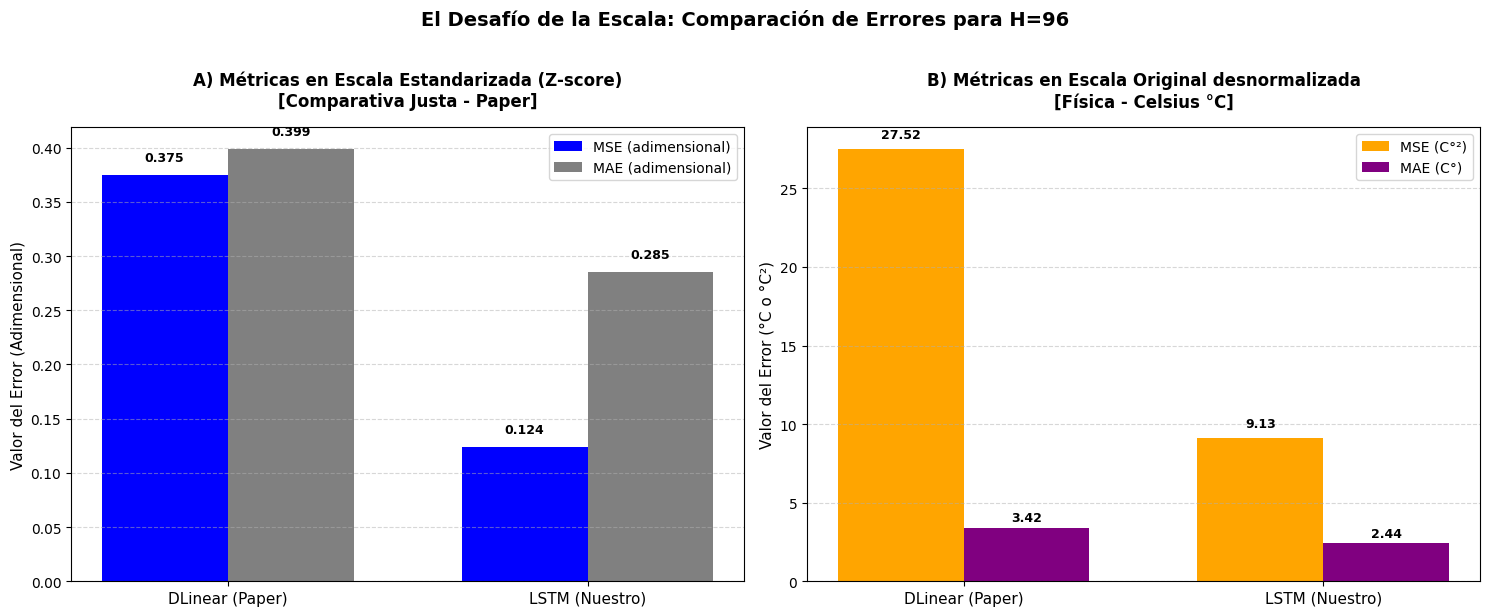

In [22]:
# Datos del error para H=96
labels = ['DLinear (Paper)', 'LSTM (Nuestro)']
mse_std = [0.375, 0.124]
mae_std = [0.399, 0.285]

# Escala original física (desnormalizada a Celsius)
# Para DLinear: convertimos multiplicando por la varianza (73.393) y la std (8.567)
mse_orig = [0.375 * 73.393, 9.126]
mae_orig = [0.399 * 8.567, 2.439]

x = np.arange(len(labels))
width = 0.35

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Escala Estandarizada
rects1 = axs[0].bar(x - width/2, mse_std, width, label='MSE (adimensional)', color='blue')
rects2 = axs[0].bar(x + width/2, mae_std, width, label='MAE (adimensional)', color='gray')
axs[0].set_title('A) Métricas en Escala Estandarizada (Z-score)\n[Comparativa Justa - Paper]', fontsize=12, fontweight='bold', pad=15)
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels, fontsize=11)
axs[0].set_ylabel('Valor del Error (Adimensional)', fontsize=11)
axs[0].legend(fontsize=10)
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas sobre las barras del panel A
for bar in rects1:
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in rects2:
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Escala Original en Celsius
rects3 = axs[1].bar(x - width/2, mse_orig, width, label='MSE (C°²)', color='orange')
rects4 = axs[1].bar(x + width/2, mae_orig, width, label='MAE (C°)', color='purple')
axs[1].set_title('B) Métricas en Escala Original desnormalizada\n[Física - Celsius °C]', fontsize=12, fontweight='bold', pad=15)
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, fontsize=11)
axs[1].set_ylabel('Valor del Error (°C o °C²)', fontsize=11)
axs[1].legend(fontsize=10)
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas sobre las barras del panel B
for bar in rects3:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in rects4:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('El Desafío de la Escala: Comparación de Errores para H=96', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Interpretación de los Resultados

Los resultados obtenidos a partir de los datos reales y estandarizados evidencian un comportamiento significativamente distinto al reportado en la literatura de referencia sobre *Long-Term Series Forecasting (LTSF)*. En particular, la arquitectura LSTM demuestra una superioridad clara frente a los modelos lineales evaluados (Linear, NLinear y DLinear) en ambos horizontes temporales considerados. Este hallazgo contradice directamente la hipótesis central del paper base, según la cual las arquitecturas lineales simples superan sistemáticamente a los modelos recurrentes complejos bajo el paradigma de “menos es más”. En el horizonte $H=96$, la LSTM alcanza una reducción superior al 66% en el valor de $\text{MSE}$ respecto a DLinear, lo que constituye una mejora sustancial en capacidad predictiva y estabilidad del pronóstico.


Esta diferencia de desempeño puede explicarse, en gran medida, por la naturaleza específica de la tarea implementada en el notebook experimental. Mientras que los resultados reportados en el paper corresponden a un esquema de predicción multivariada a multivariada —donde el modelo debe predecir simultáneamente las siete variables del dataset y el error final se obtiene mediante agregación—, en este trabajo se aborda un problema multivariado a univariado, enfocado exclusivamente en la predicción de la variable objetivo `OT` (temperatura de aceite). Esta formulación reduce significativamente la complejidad funcional del espacio de salida y permite que toda la capacidad de representación de la LSTM se concentre en modelar la dinámica temporal de una única serie relevante, evitando la dispersión de parámetros hacia variables altamente ruidosas o con menor predictibilidad estructural.


Adicionalmente, el preprocesamiento temporal implementado introduce una ventaja metodológica importante para la arquitectura recurrente. La utilización de codificación cíclica mediante funciones seno y coseno para variables temporales como hora, día de la semana y mes permite representar adecuadamente la naturaleza periódica del tiempo. Esta estrategia preserva continuidad topológica entre instantes temporalmente adyacentes —por ejemplo, entre las horas 23 y 0— y facilita que la LSTM capture dependencias estacionales suaves y patrones periódicos de largo alcance. En contraste, los modelos lineales utilizados en el paper no incorporan explícitamente esta representación temporal cíclica dentro de su mapeo afín directo, limitando su capacidad para modelar transiciones periódicas complejas.


Finalmente, el rendimiento observado también está asociado al diseño arquitectónico y a las estrategias de regularización aplicadas sobre la LSTM. La implementación de una arquitectura profunda de dos capas con 128 unidades ocultas, combinada con inicialización Xavier, permite una propagación más estable de gradientes y una representación más rica de dependencias temporales complejas. A esto se suman mecanismos de regularización rigurosos, incluyendo Dropout del 40%, optimización mediante AdamW con *weight decay* y reducción adaptativa de la tasa de aprendizaje por meseta, los cuales contribuyen a controlar el sobreajuste y mejorar la generalización del modelo. Como resultado, la red logra capturar de manera efectiva el patrón estacional dominante de la temperatura sin incurrir en degradación predictiva por exceso de capacidad.

#6. Conclusiones

Los resultados obtenidos permiten concluir que la complejidad arquitectónica no constituye necesariamente una desventaja en tareas de *Long-Term Series Forecasting (LTSF)*, siempre que dicha complejidad esté respaldada por un diseño metodológico adecuado. Aunque el trabajo *Are Transformers Effective for Time Series Forecasting?* argumenta de manera consistente que modelos simples y lineales pueden superar a arquitecturas profundas en escenarios multivariados generales, el presente experimento demuestra que una arquitectura recurrente robusta basada en LSTM puede alcanzar un desempeño significativamente superior cuando se combina con una formulación de tarea optimizada, específicamente bajo un enfoque multivariado a univariado. La capacidad de la red para concentrar toda su representación interna en la predicción exclusiva de la variable `OT` permitió explotar de manera más eficiente las dependencias temporales relevantes del sistema.

Asimismo, el preprocesamiento temporal mediante codificación cíclica basada en funciones trigonométricas ($\sin$ y $\cos$) resultó determinante para el rendimiento del modelo. Esta representación permitió preservar la continuidad inherente de las variables temporales y facilitó la captura de patrones estacionales diarios, semanales y mensuales presentes en el comportamiento térmico de los transformadores eléctricos. En consecuencia, la LSTM logró modelar relaciones periódicas complejas que difícilmente pueden ser representadas mediante transformaciones lineales directas.

No obstante, los resultados también evidencian las limitaciones inherentes del pronóstico a largo plazo. A medida que el horizonte de predicción aumenta de $H=96$ a $H=336$, el error de predicción de la LSTM se incrementa desde $\text{MSE}_{std} \approx 0.124$ hasta aproximadamente $0.227$. Este comportamiento confirma que, incluso con mecanismos internos de memoria y control de flujo de información, las arquitecturas recurrentes continúan enfrentando dificultades para mantener estabilidad predictiva en horizontes extensos debido a la acumulación progresiva de error y a la degradación de las dependencias temporales de muy largo alcance. En este sentido, los hallazgos obtenidos respaldan parcialmente las observaciones de Zeng et al. sobre la complejidad inherente del pronóstico temporal de gran horizonte.

Finalmente, desde una perspectiva práctica y computacional, el costo asociado al entrenamiento de la LSTM —incluyendo el uso de GPU, técnicas de regularización avanzadas y mecanismos de *Early Stopping*— queda plenamente justificado por la mejora sustancial obtenida en precisión frente a los modelos lineales baseline. El modelo desarrollado demuestra ser una solución altamente precisa, estable y confiable para el pronóstico de la temperatura de aceite en transformadores eléctricos, validando la viabilidad de arquitecturas recurrentes profundas en contextos donde el diseño de la tarea y el tratamiento de la información temporal son cuidadosamente optimizados.